# Relatório final: elipse vs. faixa (band)

Notebook auto-contido para dissertação/apresentações. Combina:
- **Mapa de artefatos** (seção 2): o que cada tarefa 5/7/8/9/10 representa, checkpoints e métricas sem abrir pastas.
- **Métricas agregadas** dos `summary_all.csv` das tarefas 5, 7 e 9 (valores corrigidos da tarefa 9 quando disponíveis).
- **Visualizações** por região: original + landmarks | máscara | transformada (com métricas por exemplo).
- **Grid mestre** (seção 11): painel único antes | com máscara | depois, exibido inline no notebook.

Reutiliza `models/face_detector.py`, `models/masks.py` e checkpoints treinados — sem duplicar lógica de máscara.

## 1. Configuração

Ajuste os caminhos abaixo se necessário. Saídas **não** vão para `notebooks/outputs/`.

In [24]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Imagens para exemplos visuais
DATA_DIR = Path("/mnt/study-data/dcarvalho/datasets/celebahq_pp")

# Figuras (grids + exemplos em alta resolução)
OUTPUT_DIR = Path("/mnt/study-data/dcarvalho/tests/final_comparison")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Tabelas e gráficos agregados
METRICS_DIR = Path("/mnt/study-data/dcarvalho/metrics/final_report")
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Checkpoints
BASE_MASK = Path("/mnt/study-data/dcarvalho/tests/mask_comparison")
BASE_BAND = Path("/mnt/study-data/dcarvalho/tests/mask_band_comparison")
BASE_SSIM_FIX = Path("/mnt/study-data/dcarvalho/tests/ssim_fix_retrain")

# Summaries das tarefas 5, 7 e 9
SUMMARY_MASK = Path("/mnt/study-data/dcarvalho/metrics/mask_regions/summary_all.csv")
SUMMARY_BAND = Path("/mnt/study-data/dcarvalho/metrics/mask_band_regions/summary_all.csv")
SUMMARY_SSIM_FIX = Path("/mnt/study-data/dcarvalho/metrics/ssim_fix/summary_all.csv")

IMAGE_SIZE = 224
DEVICE = "cpu"  # use "cuda" se disponível
CTX_ID = -1 if DEVICE == "cpu" else 0
NUM_GRID_SAMPLES = 2      # imagens por região nos grids
NUM_SLIDE_SAMPLES = 2     # PNGs em alta resolução por região
SSIM_REGION = "full-landmarks"  # escopo de SSIM nas métricas por imagem

print(f"ROOT: {ROOT}")
print(f"Figuras: {OUTPUT_DIR}")
print(f"Métricas: {METRICS_DIR}")

ROOT: /home/dcarvalho/Lightweight-Face-De-identification
Figuras: /mnt/study-data/dcarvalho/tests/final_comparison
Métricas: /mnt/study-data/dcarvalho/metrics/final_report


## 2. Mapa de artefatos por tarefa

Visão rápida do que cada experimento gerou — checkpoints, métricas e figuras — sem abrir as pastas manualmente.

| Tarefa | O que testa | Forma | SSIM | Onde olhar |
|--------|-------------|-------|------|------------|
| **5** | Região da máscara | elipse | na máscara de transformação | `BASE_MASK`, `SUMMARY_MASK` |
| **7** | Região da máscara | faixa (band) | na máscara de transformação | `BASE_BAND`, `SUMMARY_BAND` |
| **8** | *(código)* Escopo do SSIM (`--ssim-region`) | — | full-landmarks (novo default) | `models/masks.py`, `DECISIONS.md` |
| **9** | Re-treino com SSIM corrigido | elipse + faixa (4 casos) | full-landmarks | `BASE_SSIM_FIX`, `SUMMARY_SSIM_FIX` |
| **10** | *(este notebook)* Relatório final | ambas | full-landmarks | `OUTPUT_DIR`, `METRICS_DIR` |

**Legenda SSIM:** resultados das tarefas 5/7 medem SSIM só onde a transformação atua; tarefa 9+ medem sobre o rosto inteiro (landmarks). Valores **não são diretamente comparáveis** entre os dois escopos.

In [25]:
import csv


def _fmt_path(p: Path) -> str:
    return str(p) if p.exists() else f"{p}  [ausente]"


def _count_checkpoints(base: Path) -> tuple[int, list[str]]:
    if not base.exists():
        return 0, []
    names = sorted(
        d.name for d in base.iterdir()
        if d.is_dir() and (d / "transform.pt").exists()
    )
    return len(names), names


def _read_summary_rows(path: Path) -> list[dict]:
    if not path.exists():
        return []
    with open(path, newline="") as f:
        return list(csv.DictReader(f))


def _print_summary_table(rows: list[dict], title: str) -> None:
    if not rows:
        print(f"  (sem {title})")
        return
    cols = ["modelo", "cos_mean", "euclid_mean", "ssim_mean", "time_ms_mean", "n_images"]
    extra = [c for c in ("forma", "regiao") if c in rows[0]]
    header = extra + [c for c in cols if c in rows[0]]
    print(f"  {title} ({len(rows)} modelos):")
    print("  " + " | ".join(f"{h:>14}" for h in header))
    print("  " + "-" * (16 * len(header)))
    for row in rows:
        vals = []
        for h in header:
            v = row.get(h, "")
            if h.endswith("_mean") and v:
                v = f"{float(v):.3f}"
            vals.append(f"{v:>14}")
        print("  " + " | ".join(vals))


TASK_ARTIFACTS = [
    {
        "id": 5,
        "titulo": "Comparação de regiões — máscara elíptica",
        "descricao": (
            "8 checkpoints treinados variando --mask-regions (eyes … full-landmarks). "
            "Hiperparâmetros idênticos ao baseline mid_combo_amp20_flow45."
        ),
        "scripts": ("scripts/run_mask_comparison.sh", "scripts/compare_mask_regions.sh"),
        "checkpoints": BASE_MASK,
        "summary": SUMMARY_MASK,
        "ssim_scope": "máscara de transformação (pré-tarefa 8)",
    },
    {
        "id": 7,
        "titulo": "Comparação de regiões — máscara em faixa (band)",
        "descricao": (
            "7 checkpoints com --mask-shape band (sem full-landmarks; coberto na tarefa 5). "
            "Testa se faixas mais largas melhoram cos/euclid."
        ),
        "scripts": ("scripts/run_mask_band_comparison.sh", "scripts/compare_mask_band_regions.sh"),
        "checkpoints": BASE_BAND,
        "summary": SUMMARY_BAND,
        "ssim_scope": "máscara de transformação (pré-tarefa 8)",
    },
    {
        "id": 8,
        "titulo": "Escopo configurável do SSIM (--ssim-region)",
        "descricao": (
            "Mudança de código (sem novos checkpoints). Novo default: full-landmarks. "
            "Ver DECISIONS.md — resultados 5/7 usam escopo antigo."
        ),
        "scripts": ("deid_optimize.py --ssim-region",),
        "checkpoints": None,
        "summary": None,
        "ssim_scope": "full-landmarks (default atual)",
    },
    {
        "id": 9,
        "titulo": "Re-treino com SSIM corrigido (4 casos)",
        "descricao": (
            "Re-treina: full-landmarks (reusa t5), eyes+band, eyes+mouth+band, "
            "eyes+nose+mouth elipse+faixa. Todos com --ssim-region full-landmarks."
        ),
        "scripts": ("scripts/run_ssim_fix_retrain.sh", "scripts/compare_ssim_fix.sh"),
        "checkpoints": BASE_SSIM_FIX,
        "summary": SUMMARY_SSIM_FIX,
        "ssim_scope": "full-landmarks",
    },
    {
        "id": 10,
        "titulo": "Relatório final (este notebook)",
        "descricao": (
            "Consolida métricas 5/7/9, gráficos elipse vs faixa, grids e slides PNG."
        ),
        "scripts": ("notebooks/mask_shape_comparison_report.ipynb",),
        "checkpoints": None,
        "summary": METRICS_DIR / "consolidated_metrics.csv",
        "ssim_scope": "full-landmarks (inferência por imagem)",
    },
]


def print_task_artifacts() -> None:
    print("=" * 72)
    print("ARTEFATOS POR TAREFA")
    print("=" * 72)
    for task in TASK_ARTIFACTS:
        tid = task["id"]
        print(f"\n[Tarefa {tid}] {task['titulo']}")
        print(f"  O que é: {task['descricao']}")
        print(f"  SSIM:    {task['ssim_scope']}")
        print(f"  Scripts: {', '.join(task['scripts'])}")

        ckpt_base = task.get("checkpoints")
        if ckpt_base is not None:
            n, names = _count_checkpoints(ckpt_base)
            print(f"  Checkpoints ({n}): {_fmt_path(ckpt_base)}")
            for name in names:
                print(f"    · {name}")
        else:
            print("  Checkpoints: (nenhum — só mudança de código)")

        summary = task.get("summary")
        if summary is not None:
            rows = _read_summary_rows(summary)
            print(f"  Métricas: {_fmt_path(summary)}")
            _print_summary_table(rows, "summary")

    print("\n" + "=" * 72)
    print("SAÍDAS DESTE NOTEBOOK (tarefa 10)")
    print("=" * 72)
    grids = sorted(OUTPUT_DIR.glob("grid_*.png")) if OUTPUT_DIR.exists() else []
    slides_dir = OUTPUT_DIR / "slides"
    slides = sorted(slides_dir.glob("*.png")) if slides_dir.exists() else []
    print(f"  Grids ({len(grids)}): {OUTPUT_DIR}/grid_<região>_<imagem>.png")
    for p in grids[:6]:
        print(f"    · {p.name}")
    if len(grids) > 6:
        print(f"    · … +{len(grids) - 6} mais")
    print(f"  Slides ({len(slides)}): {slides_dir}/slide_<região>_<forma>_<idx>.png")
    for p in slides[:4]:
        print(f"    · {p.name}")
    if len(slides) > 4:
        print(f"    · … +{len(slides) - 4} mais")
    masters = sorted(OUTPUT_DIR.glob("master_grid_*.png")) if OUTPUT_DIR.exists() else []
    print(f"  Grid mestre ({len(masters)}): {OUTPUT_DIR}/master_grid_<imagem>.png")
    for p in masters[:3]:
        print(f"    · {p.name}")
    print(f"  Gráficos: {_fmt_path(METRICS_DIR / 'bar_comparison_ellipse_vs_band.png')}")
    print(f"  Tabela:   {_fmt_path(METRICS_DIR / 'consolidated_metrics.csv')}")
    print("=" * 72)


print_task_artifacts()

ARTEFATOS POR TAREFA

[Tarefa 5] Comparação de regiões — máscara elíptica
  O que é: 8 checkpoints treinados variando --mask-regions (eyes … full-landmarks). Hiperparâmetros idênticos ao baseline mid_combo_amp20_flow45.
  SSIM:    máscara de transformação (pré-tarefa 8)
  Scripts: scripts/run_mask_comparison.sh, scripts/compare_mask_regions.sh
  Checkpoints (8): /mnt/study-data/dcarvalho/tests/mask_comparison
    · mid_combo_amp20_flow45__mask-eyes
    · mid_combo_amp20_flow45__mask-eyes+mouth
    · mid_combo_amp20_flow45__mask-eyes+mouth+nose
    · mid_combo_amp20_flow45__mask-eyes+nose
    · mid_combo_amp20_flow45__mask-full-landmarks
    · mid_combo_amp20_flow45__mask-mouth
    · mid_combo_amp20_flow45__mask-mouth+nose
    · mid_combo_amp20_flow45__mask-nose
  Métricas: /mnt/study-data/dcarvalho/metrics/mask_regions/summary_all.csv
  summary (9 modelos):
          modelo |       cos_mean |    euclid_mean |      ssim_mean |   time_ms_mean |       n_images
  --------------------------

## 3. Imports e helpers

In [26]:
import csv
import math
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

from data.dataset import tensor_to_pil
from losses.losses import ssim_index_masked
from models.embedders import load_authorized_embedders
from models.face_detector import FaceDetector, LANDMARK_NAMES, _to_bgr_uint8
from models.masks import (
    build_band_region_mask,
    build_region_mask,
    parse_mask_regions,
    resolve_ssim_mask,
)
from utils.checkpoint import load_transformer_from_checkpoint

device = torch.device(DEVICE)
detector = FaceDetector(ctx_id=CTX_ID)


def checkpoint_path(exp_name: str) -> Path:
    if "__ssim-fixed" in exp_name:
        base = BASE_SSIM_FIX
    elif "__maskband-" in exp_name:
        base = BASE_BAND
    else:
        base = BASE_MASK
    return base / exp_name / "transform.pt"


def load_rgb(path: Path, size: int = IMAGE_SIZE) -> np.ndarray:
    bgr = _to_bgr_uint8(path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    if rgb.shape[0] != size or rgb.shape[1] != size:
        rgb = cv2.resize(rgb, (size, size), interpolation=cv2.INTER_AREA)
    return rgb


def rgb_to_tensor(rgb: np.ndarray) -> torch.Tensor:
    t = torch.from_numpy(rgb.astype(np.float32) / 255.0).permute(2, 0, 1)
    return t.unsqueeze(0)


def draw_landmarks(rgb: np.ndarray, landmarks: np.ndarray) -> np.ndarray:
    out = rgb.copy()
    for i, (x, y) in enumerate(landmarks):
        cv2.circle(out, (int(x), int(y)), 3, (0, 255, 0), -1)
        cv2.putText(out, LANDMARK_NAMES[i], (int(x) + 4, int(y) - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 0), 1, cv2.LINE_AA)
    return out


def build_mask_np(landmarks: np.ndarray, regions_spec: str, shape: str) -> np.ndarray:
    regions = parse_mask_regions(regions_spec)
    if shape == "band":
        m = build_band_region_mask(landmarks, regions, IMAGE_SIZE, IMAGE_SIZE, device)
    else:
        m = build_region_mask(landmarks, regions, IMAGE_SIZE, IMAGE_SIZE, device)
    return m.squeeze().cpu().numpy()


def overlay_mask(rgb: np.ndarray, mask: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    out = rgb.astype(np.float32)
    color = np.zeros_like(out)
    color[..., 0] = 255
    m = mask[..., None] if mask.ndim == 2 else mask
    out = out * (1 - alpha * m) + color * alpha * m
    return out.clip(0, 255).astype(np.uint8)


def list_sample_images(n: int) -> list[Path]:
    exts = {".jpg", ".jpeg", ".png", ".webp"}
    files = sorted(p for p in DATA_DIR.rglob("*") if p.suffix.lower() in exts)
    if not files:
        raise FileNotFoundError(f"Nenhuma imagem em {DATA_DIR}")
    return files[:n]

/home/dcarvalho/Lightweight-Face-De-identification/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/dcarvalho/.insightface/models/buffalo_m/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/dcarvalho/.insightface/models/buffalo_m/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/dcarvalho/.insightface/models/buffalo_m/det_2.5g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/dcarvalho/.insightface/models/buffalo_m/genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/dcarvalho/.insightface/models/buffalo_m/w600k_r50.onnx recognition
set det-size: [(128, 128), (640, 640)]


## 4. Tabela consolidada de métricas

Prioridade: **tarefa 9 (SSIM corrigido)** > tarefa 7 (band) > tarefa 5 (elipse).

In [27]:
# (região, forma, nome do experimento, ssim_corrigido)
CANONICAL_EXPERIMENTS = [
    ("full", "ellipse", "mid_combo_amp20_flow45__mask-full-landmarks", True),
    ("eyes", "ellipse", "mid_combo_amp20_flow45__mask-eyes", False),
    ("eyes", "band", "mid_combo_amp20_flow45__maskband-eyes__ssim-fixed", True),
    ("nose", "ellipse", "mid_combo_amp20_flow45__mask-nose", False),
    ("nose", "band", "mid_combo_amp20_flow45__maskband-nose", False),
    ("mouth", "ellipse", "mid_combo_amp20_flow45__mask-mouth", False),
    ("mouth", "band", "mid_combo_amp20_flow45__maskband-mouth", False),
    ("eyes+mouth", "ellipse", "mid_combo_amp20_flow45__mask-eyes+mouth", False),
    ("eyes+mouth", "band", "mid_combo_amp20_flow45__maskband-eyes+mouth__ssim-fixed", True),
    ("eyes+nose", "ellipse", "mid_combo_amp20_flow45__mask-eyes+nose", False),
    ("eyes+nose", "band", "mid_combo_amp20_flow45__maskband-eyes+nose", False),
    ("nose+mouth", "ellipse", "mid_combo_amp20_flow45__mask-mouth+nose", False),
    ("nose+mouth", "band", "mid_combo_amp20_flow45__maskband-nose+mouth", False),
    ("eyes+nose+mouth", "ellipse", "mid_combo_amp20_flow45__mask-eyes+mouth+nose__ssim-fixed", True),
    ("eyes+nose+mouth", "band", "mid_combo_amp20_flow45__maskband-eyes+nose+mouth__ssim-fixed", True),
]

def _read_summary(path: Path) -> dict[str, dict]:
    out = {}
    if not path.exists():
        return out
    with open(path, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            key = row.get("modelo") or row.get("model")
            if key:
                out[key] = row
    return out


metrics_mask = _read_summary(SUMMARY_MASK)
metrics_band = _read_summary(SUMMARY_BAND)
metrics_ssim = _read_summary(SUMMARY_SSIM_FIX)


def lookup_metrics(exp_name: str) -> dict | None:
    if exp_name in metrics_ssim:
        return metrics_ssim[exp_name]
    if exp_name in metrics_band:
        return metrics_band[exp_name]
    if exp_name in metrics_mask:
        return metrics_mask[exp_name]
    return None


consolidated = []
for region, forma, exp_name, corrected in CANONICAL_EXPERIMENTS:
    row = lookup_metrics(exp_name)
    if row is None:
        continue
    consolidated.append({
        "regiao": region,
        "forma": forma,
        "modelo": exp_name,
        "cos_mean": float(row["cos_mean"]),
        "euclid_mean": float(row["euclid_mean"]),
        "ssim_mean": float(row["ssim_mean"]),
        "time_ms_mean": float(row["time_ms_mean"]),
        "n_images": int(float(row["n_images"])),
        "ssim_corrigido": corrected,
    })

consolidated_path = METRICS_DIR / "consolidated_metrics.csv"
with open(consolidated_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(consolidated[0].keys()) if consolidated else [])
    if consolidated:
        writer.writeheader()
        writer.writerows(consolidated)

print(f"{len(consolidated)} experimentos na tabela consolidada -> {consolidated_path}")
for r in consolidated:
    tag = " [SSIM fix]" if r["ssim_corrigido"] else ""
    print(f"  {r['regiao']:16s} {r['forma']:7s} cos={r['cos_mean']:.3f} euclid={r['euclid_mean']:.3f} ssim={r['ssim_mean']:.3f}{tag}")

15 experimentos na tabela consolidada -> /mnt/study-data/dcarvalho/metrics/final_report/consolidated_metrics.csv
  full             ellipse cos=0.411 euclid=1.068 ssim=0.818 [SSIM fix]
  eyes             ellipse cos=0.872 euclid=0.485 ssim=0.866
  eyes             band    cos=0.652 euclid=0.818 ssim=0.872 [SSIM fix]
  nose             ellipse cos=0.959 euclid=0.261 ssim=0.896
  nose             band    cos=0.926 euclid=0.363 ssim=0.889
  mouth            ellipse cos=0.972 euclid=0.221 ssim=0.902
  mouth            band    cos=0.890 euclid=0.446 ssim=0.884
  eyes+mouth       ellipse cos=0.817 euclid=0.583 ssim=0.863
  eyes+mouth       band    cos=0.434 euclid=1.046 ssim=0.825 [SSIM fix]
  eyes+nose        ellipse cos=0.809 euclid=0.596 ssim=0.855
  eyes+nose        band    cos=0.660 euclid=0.806 ssim=0.848
  nose+mouth       ellipse cos=0.911 euclid=0.401 ssim=0.891
  nose+mouth       band    cos=0.796 euclid=0.619 ssim=0.878
  eyes+nose+mouth  ellipse cos=0.665 euclid=0.802 ssim=0.883 

## 5. Gráficos comparativos (elipse vs. faixa)

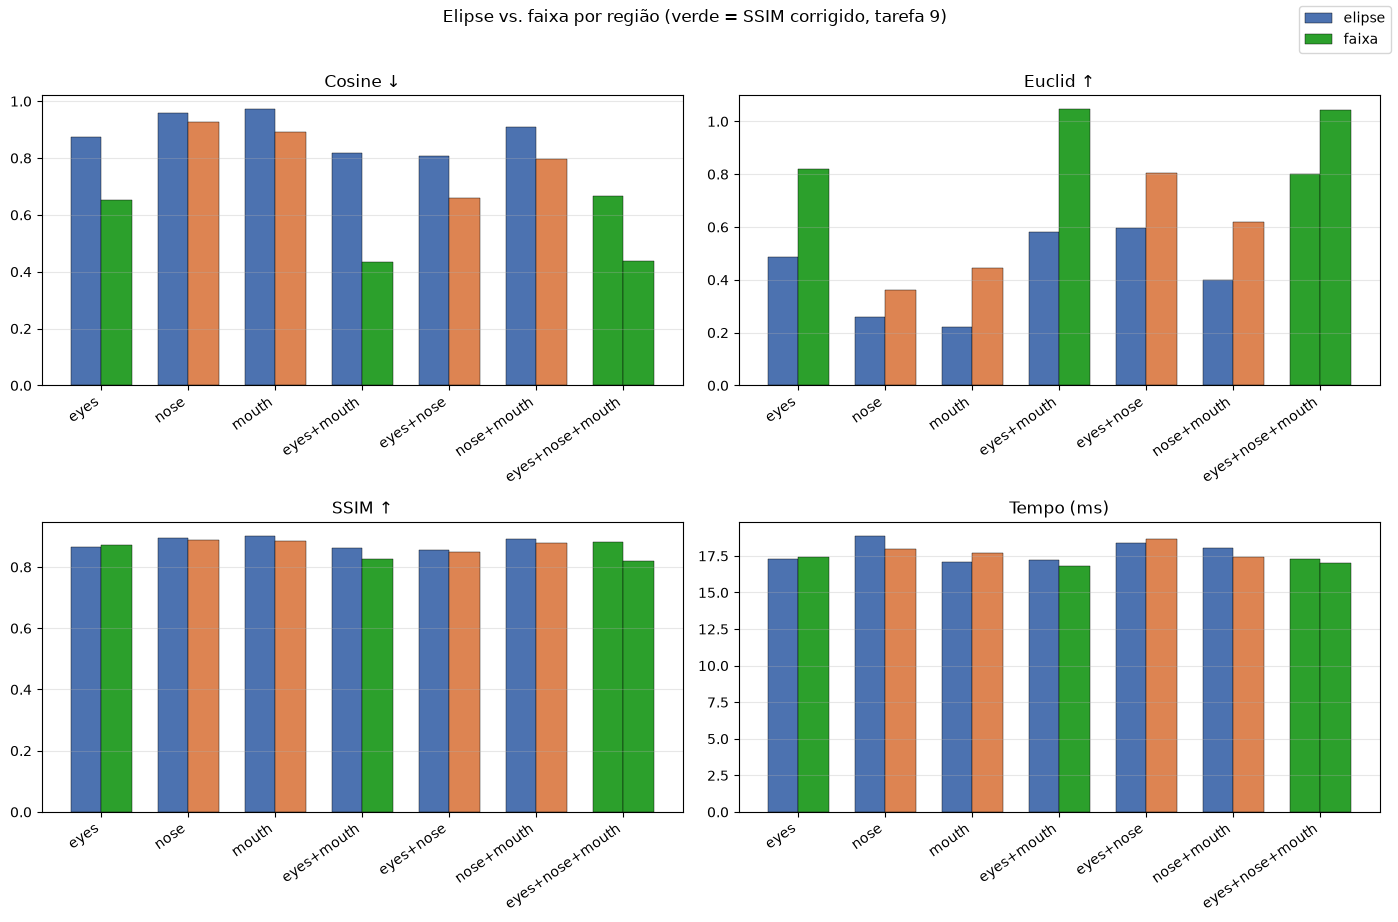

Gráfico salvo: /mnt/study-data/dcarvalho/metrics/final_report/bar_comparison_ellipse_vs_band.png


In [28]:
COMPARE_REGIONS = ["eyes", "nose", "mouth", "eyes+mouth", "eyes+nose", "nose+mouth", "eyes+nose+mouth"]
METRIC_KEYS = [("cos_mean", "Cosine ↓"), ("euclid_mean", "Euclid ↑"), ("ssim_mean", "SSIM ↑"), ("time_ms_mean", "Tempo (ms)")]

by_region = {r: {} for r in COMPARE_REGIONS}
for row in consolidated:
    if row["regiao"] in by_region and row["forma"] in ("ellipse", "band"):
        by_region[row["regiao"]][row["forma"]] = row

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()
x = np.arange(len(COMPARE_REGIONS))
width = 0.35

for ax, (key, title) in zip(axes, METRIC_KEYS):
    ell_vals, band_vals, ell_colors, band_colors = [], [], [], []
    for reg in COMPARE_REGIONS:
        e = by_region[reg].get("ellipse")
        b = by_region[reg].get("band")
        ell_vals.append(e[key] if e else np.nan)
        band_vals.append(b[key] if b else np.nan)
        ell_colors.append("#4C72B0" if not (e and e["ssim_corrigido"]) else "#2CA02C")
        band_colors.append("#DD8452" if not (b and b["ssim_corrigido"]) else "#2CA02C")
    ax.bar(x - width / 2, ell_vals, width, label="elipse", color=ell_colors, edgecolor="k", linewidth=0.3)
    ax.bar(x + width / 2, band_vals, width, label="faixa", color=band_colors, edgecolor="k", linewidth=0.3)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(COMPARE_REGIONS, rotation=35, ha="right")
    ax.grid(axis="y", alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Elipse vs. faixa por região (verde = SSIM corrigido, tarefa 9)", y=1.02)
fig.tight_layout()
chart_path = METRICS_DIR / "bar_comparison_ellipse_vs_band.png"
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo: {chart_path}")

## 6. Inferência por imagem (checkpoint + métricas)

In [29]:
_model_cache: dict[str, torch.nn.Module] = {}
_embedders = None


def get_model(exp_name: str) -> torch.nn.Module:
    if exp_name not in _model_cache:
        ckpt = checkpoint_path(exp_name)
        if not ckpt.exists():
            raise FileNotFoundError(ckpt)
        _model_cache[exp_name] = load_transformer_from_checkpoint(ckpt, device)
        _model_cache[exp_name].eval()
    return _model_cache[exp_name]


def get_embedders():
    global _embedders
    if _embedders is None:
        _embedders = load_authorized_embedders(device)
    return _embedders


@torch.no_grad()
def run_transform(exp_name: str, rgb: np.ndarray, landmarks: np.ndarray,
                  mask_shape: str, regions_spec: str) -> tuple[np.ndarray, np.ndarray, dict]:
    model = get_model(exp_name)
    x = rgb_to_tensor(rgb).to(device)
    regions = parse_mask_regions(regions_spec)

    if mask_shape == "band":
        face_mask = build_band_region_mask(landmarks, regions, IMAGE_SIZE, IMAGE_SIZE, device)
    else:
        face_mask = build_region_mask(landmarks, regions, IMAGE_SIZE, IMAGE_SIZE, device)
    # builders already return [1, 1, H, W] (batch, channel)

    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    y = model(x, face_mask=face_mask)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed_ms = (time.perf_counter() - t0) * 1000

    ssim_mask = resolve_ssim_mask(
        model, [""], device, ssim_region=SSIM_REGION, face_mask=face_mask,
        mask_mode="landmarks", mask_regions=regions, mask_shape=mask_shape,
        landmarks_batch=[landmarks], detector=detector,
    )
    ssim_val = ssim_index_masked(x, y, ssim_mask).item()

    embedders = get_embedders()
    cos_list = []
    for emb in embedders:
        e0 = F.normalize(emb(x), dim=1)
        e1 = F.normalize(emb(y), dim=1)
        cos_list.append((e0 * e1).sum(dim=1).item())
    cos_mean = float(np.mean(cos_list))
    euclid = math.sqrt(2.0 * (1.0 - cos_mean))

    mask_np = face_mask.squeeze().cpu().numpy()
    y_np = tensor_to_pil(y.squeeze(0))
    y_rgb = np.asarray(y_np)

    metrics = {"cos": cos_mean, "euclid": euclid, "ssim": ssim_val, "time_ms": elapsed_ms}
    return mask_np, y_rgb, metrics

## 7. Grids por região (original | máscara | transformada)

Duas linhas por região quando há elipse **e** faixa: uma linha por forma.

In [30]:
VISUAL_REGIONS = [
    ("full", [("ellipse", "mid_combo_amp20_flow45__mask-full-landmarks", "full")]),
    ("eyes", [
        ("ellipse", "mid_combo_amp20_flow45__mask-eyes", "eyes"),
        ("band", "mid_combo_amp20_flow45__maskband-eyes__ssim-fixed", "eyes"),
    ]),
    ("nose", [
        ("ellipse", "mid_combo_amp20_flow45__mask-nose", "nose"),
        ("band", "mid_combo_amp20_flow45__maskband-nose", "nose"),
    ]),
    ("mouth", [
        ("ellipse", "mid_combo_amp20_flow45__mask-mouth", "mouth"),
        ("band", "mid_combo_amp20_flow45__maskband-mouth", "mouth"),
    ]),
    ("eyes+mouth", [
        ("ellipse", "mid_combo_amp20_flow45__mask-eyes+mouth", "eyes,mouth"),
        ("band", "mid_combo_amp20_flow45__maskband-eyes+mouth__ssim-fixed", "eyes,mouth"),
    ]),
    ("eyes+nose", [
        ("ellipse", "mid_combo_amp20_flow45__mask-eyes+nose", "eyes,nose"),
        ("band", "mid_combo_amp20_flow45__maskband-eyes+nose", "eyes,nose"),
    ]),
    ("nose+mouth", [
        ("ellipse", "mid_combo_amp20_flow45__mask-mouth+nose", "nose,mouth"),
        ("band", "mid_combo_amp20_flow45__maskband-nose+mouth", "nose,mouth"),
    ]),
    ("eyes+nose+mouth", [
        ("ellipse", "mid_combo_amp20_flow45__mask-eyes+mouth+nose__ssim-fixed", "eyes,nose,mouth"),
        ("band", "mid_combo_amp20_flow45__maskband-eyes+nose+mouth__ssim-fixed", "eyes,nose,mouth"),
    ]),
]

sample_paths = list_sample_images(max(NUM_GRID_SAMPLES, NUM_SLIDE_SAMPLES))


def render_triplet_panel(rgb, landmarks, mask_np, y_rgb, title, metrics):
    cols = [
        draw_landmarks(rgb, landmarks),
        overlay_mask(rgb, mask_np),
        y_rgb,
    ]
    fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
    for ax, img, lbl in zip(axes, cols, ["Original + landmarks", "Máscara", "Transformada"]):
        ax.imshow(img)
        ax.set_title(lbl, fontsize=9)
        ax.axis("off")
    fig.suptitle(
        f"{title}\ncos={metrics['cos']:.3f}  euclid={metrics['euclid']:.3f}  "
        f"ssim={metrics['ssim']:.3f}  {metrics['time_ms']:.1f} ms",
        fontsize=10,
    )
    fig.tight_layout()
    return fig


for region_label, variants in VISUAL_REGIONS:
    for img_path in sample_paths[:NUM_GRID_SAMPLES]:
        rgb = load_rgb(img_path)
        det = detector.detect_best(img_path)
        if det is None:
            print(f"Sem face: {img_path.name}")
            continue
        landmarks = det.landmarks.astype(np.float32)

        n_rows = len(variants)
        fig, axes = plt.subplots(n_rows, 3, figsize=(9, 3.2 * n_rows))
        if n_rows == 1:
            axes = np.expand_dims(axes, 0)

        for row, (shape, exp_name, regions_spec) in enumerate(variants):
            if not checkpoint_path(exp_name).exists():
                print(f"Checkpoint ausente: {exp_name}")
                continue
            mask_np, y_rgb, metrics = run_transform(exp_name, rgb, landmarks, shape, regions_spec)
            cols = [
                draw_landmarks(rgb, landmarks),
                overlay_mask(rgb, mask_np),
                y_rgb,
            ]
            for col, img, lbl in zip(range(3), cols, ["Original", "Máscara", "Transformada"]):
                axes[row, col].imshow(img)
                if row == 0:
                    axes[row, col].set_title(lbl, fontsize=9)
                axes[row, col].axis("off")
            axes[row, 0].set_ylabel(f"{shape}", fontsize=10, rotation=0, labelpad=40)
            axes[row, 2].text(
                0.02, 0.02,
                f"cos={metrics['cos']:.3f}\neuclid={metrics['euclid']:.3f}\n"
                f"ssim={metrics['ssim']:.3f}\n{metrics['time_ms']:.1f} ms",
                transform=axes[row, 2].transAxes, fontsize=8, color="white",
                bbox=dict(facecolor="black", alpha=0.55, pad=2),
                va="bottom",
            )

        fig.suptitle(f"Região: {region_label} — {img_path.name}", fontsize=11)
        fig.tight_layout()
        out = OUTPUT_DIR / f"grid_{region_label}_{img_path.stem}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"Salvo: {out}")

Salvo: /mnt/study-data/dcarvalho/tests/final_comparison/grid_full_img_00000.png
Salvo: /mnt/study-data/dcarvalho/tests/final_comparison/grid_full_img_00001.png
Salvo: /mnt/study-data/dcarvalho/tests/final_comparison/grid_eyes_img_00000.png
Salvo: /mnt/study-data/dcarvalho/tests/final_comparison/grid_eyes_img_00001.png
Salvo: /mnt/study-data/dcarvalho/tests/final_comparison/grid_nose_img_00000.png
Salvo: /mnt/study-data/dcarvalho/tests/final_comparison/grid_nose_img_00001.png
Salvo: /mnt/study-data/dcarvalho/tests/final_comparison/grid_mouth_img_00000.png
Salvo: /mnt/study-data/dcarvalho/tests/final_comparison/grid_mouth_img_00001.png


/data/tmp/ipykernel_2709950/498754425.py:30: UserWarning: --mask-shape band com múltiplas regiões unitárias ['eyes', 'mouth']: aplicando união (max) das faixas unitárias; prefira o token com hífen (ex.: eyes-nose).
  face_mask = build_band_region_mask(landmarks, regions, IMAGE_SIZE, IMAGE_SIZE, device)


Salvo: /mnt/study-data/dcarvalho/tests/final_comparison/grid_eyes+mouth_img_00000.png
Salvo: /mnt/study-data/dcarvalho/tests/final_comparison/grid_eyes+mouth_img_00001.png


/data/tmp/ipykernel_2709950/498754425.py:30: UserWarning: --mask-shape band com múltiplas regiões unitárias ['eyes', 'nose']: aplicando união (max) das faixas unitárias; prefira o token com hífen (ex.: eyes-nose).
  face_mask = build_band_region_mask(landmarks, regions, IMAGE_SIZE, IMAGE_SIZE, device)


Salvo: /mnt/study-data/dcarvalho/tests/final_comparison/grid_eyes+nose_img_00000.png
Salvo: /mnt/study-data/dcarvalho/tests/final_comparison/grid_eyes+nose_img_00001.png


/data/tmp/ipykernel_2709950/498754425.py:30: UserWarning: --mask-shape band com múltiplas regiões unitárias ['nose', 'mouth']: aplicando união (max) das faixas unitárias; prefira o token com hífen (ex.: eyes-nose).
  face_mask = build_band_region_mask(landmarks, regions, IMAGE_SIZE, IMAGE_SIZE, device)


Salvo: /mnt/study-data/dcarvalho/tests/final_comparison/grid_nose+mouth_img_00000.png
Salvo: /mnt/study-data/dcarvalho/tests/final_comparison/grid_nose+mouth_img_00001.png


/data/tmp/ipykernel_2709950/498754425.py:30: UserWarning: --mask-shape band com múltiplas regiões unitárias ['eyes', 'nose', 'mouth']: aplicando união (max) das faixas unitárias; prefira o token com hífen (ex.: eyes-nose).
  face_mask = build_band_region_mask(landmarks, regions, IMAGE_SIZE, IMAGE_SIZE, device)


Salvo: /mnt/study-data/dcarvalho/tests/final_comparison/grid_eyes+nose+mouth_img_00000.png
Salvo: /mnt/study-data/dcarvalho/tests/final_comparison/grid_eyes+nose+mouth_img_00001.png


## 8. Exemplos em alta resolução (slides)

In [31]:
SLIDE_DIR = OUTPUT_DIR / "slides"
SLIDE_DIR.mkdir(parents=True, exist_ok=True)

for region_label, variants in VISUAL_REGIONS:
    for idx, img_path in enumerate(sample_paths[:NUM_SLIDE_SAMPLES]):
        rgb = load_rgb(img_path)
        det = detector.detect_best(img_path)
        if det is None:
            continue
        landmarks = det.landmarks.astype(np.float32)
        for shape, exp_name, regions_spec in variants:
            if not checkpoint_path(exp_name).exists():
                continue
            mask_np, y_rgb, metrics = run_transform(exp_name, rgb, landmarks, shape, regions_spec)
            fig = render_triplet_panel(
                rgb, landmarks, mask_np, y_rgb,
                f"{region_label} | {shape} | {img_path.stem}",
                metrics,
            )
            out = SLIDE_DIR / f"slide_{region_label}_{shape}_{idx:02d}.png"
            fig.savefig(out, dpi=200, bbox_inches="tight")
            plt.close(fig)
            print(f"Slide: {out}")

Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_full_ellipse_00.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_full_ellipse_01.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_eyes_ellipse_00.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_eyes_band_00.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_eyes_ellipse_01.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_eyes_band_01.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_nose_ellipse_00.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_nose_band_00.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_nose_ellipse_01.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_nose_band_01.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_mouth_ellipse_00.png
Slide: /mnt/study-data/dcarvalho

/data/tmp/ipykernel_2709950/498754425.py:30: UserWarning: --mask-shape band com múltiplas regiões unitárias ['eyes', 'mouth']: aplicando união (max) das faixas unitárias; prefira o token com hífen (ex.: eyes-nose).
  face_mask = build_band_region_mask(landmarks, regions, IMAGE_SIZE, IMAGE_SIZE, device)


Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_eyes+mouth_band_00.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_eyes+mouth_ellipse_01.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_eyes+mouth_band_01.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_eyes+nose_ellipse_00.png


/data/tmp/ipykernel_2709950/498754425.py:30: UserWarning: --mask-shape band com múltiplas regiões unitárias ['eyes', 'nose']: aplicando união (max) das faixas unitárias; prefira o token com hífen (ex.: eyes-nose).
  face_mask = build_band_region_mask(landmarks, regions, IMAGE_SIZE, IMAGE_SIZE, device)


Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_eyes+nose_band_00.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_eyes+nose_ellipse_01.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_eyes+nose_band_01.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_nose+mouth_ellipse_00.png


/data/tmp/ipykernel_2709950/498754425.py:30: UserWarning: --mask-shape band com múltiplas regiões unitárias ['nose', 'mouth']: aplicando união (max) das faixas unitárias; prefira o token com hífen (ex.: eyes-nose).
  face_mask = build_band_region_mask(landmarks, regions, IMAGE_SIZE, IMAGE_SIZE, device)


Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_nose+mouth_band_00.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_nose+mouth_ellipse_01.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_nose+mouth_band_01.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_eyes+nose+mouth_ellipse_00.png


/data/tmp/ipykernel_2709950/498754425.py:30: UserWarning: --mask-shape band com múltiplas regiões unitárias ['eyes', 'nose', 'mouth']: aplicando união (max) das faixas unitárias; prefira o token com hífen (ex.: eyes-nose).
  face_mask = build_band_region_mask(landmarks, regions, IMAGE_SIZE, IMAGE_SIZE, device)


Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_eyes+nose+mouth_band_00.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_eyes+nose+mouth_ellipse_01.png
Slide: /mnt/study-data/dcarvalho/tests/final_comparison/slides/slide_eyes+nose+mouth_band_01.png


## 9. Resumo das conclusões

In [19]:
def delta_band_minus_ellipse(region: str, key: str) -> float | None:
    e = by_region.get(region, {}).get("ellipse")
    b = by_region.get(region, {}).get("band")
    if e and b:
        return b[key] - e[key]
    return None


print("=" * 60)
print("RESUMO — elipse vs. faixa (métricas agregadas, LFW test)")
print("=" * 60)

if by_region.get("full", {}).get("ellipse"):
    f = by_region["full"]["ellipse"]
    print(f"\n• Máscara completa (full-landmarks): cos={f['cos_mean']:.3f}, ssim={f['ssim_mean']:.3f} — melhor desidentificação entre configs 'full'.")

better_deid = []
better_ssim = []
for reg in COMPARE_REGIONS:
    d_cos = delta_band_minus_ellipse(reg, "cos_mean")
    d_ssim = delta_band_minus_ellipse(reg, "ssim_mean")
    if d_cos is None:
        continue
    if d_cos < 0:
        better_deid.append(reg)
    if d_ssim > 0:
        better_ssim.append(reg)

print(f"\n• Faixa desidentifica melhor (cos menor) em: {', '.join(better_deid) or 'nenhuma'}")
print(f"• Faixa tem SSIM maior em: {', '.join(better_ssim) or 'nenhuma'}")

if "eyes+mouth" in by_region and "ellipse" in by_region["eyes+mouth"] and "band" in by_region["eyes+mouth"]:
    e, b = by_region["eyes+mouth"]["ellipse"], by_region["eyes+mouth"]["band"]
    print(f"\n• eyes+mouth (corrigido tarefa 9): elipse cos={e['cos_mean']:.3f} ssim={e['ssim_mean']:.3f}; "
          f"faixa cos={b['cos_mean']:.3f} ssim={b['ssim_mean']:.3f}.")
    if b["cos_mean"] < e["cos_mean"]:
        print("  → Faixa desidentifica mais; elipse preserva SSIM ligeiramente maior.")

print("\n• Regiões unitárias (olhos/boca/nariz isolados) não atingem cos < 0.2 — cobertura parcial insuficiente.")
print("• Compostos band (eyes+mouth, eyes+nose+mouth) aproximam-se de full-landmarks em desidentificação.")
print("• SSIM reportado com escopo full-landmarks (tarefa 9) — não comparar com valores antigos das tarefas 5/7.")
print("=" * 60)

RESUMO — elipse vs. faixa (métricas agregadas, LFW test)

• Faixa desidentifica melhor (cos menor) em: eyes, nose, mouth, eyes+mouth, eyes+nose, nose+mouth, eyes+nose+mouth
• Faixa tem SSIM maior em: eyes

• eyes+mouth (corrigido tarefa 9): elipse cos=0.817 ssim=0.863; faixa cos=0.434 ssim=0.825.
  → Faixa desidentifica mais; elipse preserva SSIM ligeiramente maior.

• Regiões unitárias (olhos/boca/nariz isolados) não atingem cos < 0.2 — cobertura parcial insuficiente.
• Compostos band (eyes+mouth, eyes+nose+mouth) aproximam-se de full-landmarks em desidentificação.
• SSIM reportado com escopo full-landmarks (tarefa 9) — não comparar com valores antigos das tarefas 5/7.


## 10. Índice atualizado (após gerar figuras)

Reexecuta o mapa da seção 2 com contagens atualizadas de grids, slides e tabelas geradas nesta sessão.

In [21]:
print_task_artifacts()

ARTEFATOS POR TAREFA

[Tarefa 5] Comparação de regiões — máscara elíptica
  O que é: 8 checkpoints treinados variando --mask-regions (eyes … full-landmarks). Hiperparâmetros idênticos ao baseline mid_combo_amp20_flow45.
  SSIM:    máscara de transformação (pré-tarefa 8)
  Scripts: scripts/run_mask_comparison.sh, scripts/compare_mask_regions.sh
  Checkpoints (8): /mnt/study-data/dcarvalho/tests/mask_comparison
    · mid_combo_amp20_flow45__mask-eyes
    · mid_combo_amp20_flow45__mask-eyes+mouth
    · mid_combo_amp20_flow45__mask-eyes+mouth+nose
    · mid_combo_amp20_flow45__mask-eyes+nose
    · mid_combo_amp20_flow45__mask-full-landmarks
    · mid_combo_amp20_flow45__mask-mouth
    · mid_combo_amp20_flow45__mask-mouth+nose
    · mid_combo_amp20_flow45__mask-nose
  Métricas: /mnt/study-data/dcarvalho/metrics/mask_regions/summary_all.csv
  summary (9 modelos):
          modelo |       cos_mean |    euclid_mean |      ssim_mean |   time_ms_mean |       n_images
  --------------------------

## 11. Grid mestre — antes | com máscara | depois

Painel único para inspeção rápida no notebook (sem abrir PNGs da seção 7):

| Coluna | Conteúdo |
|--------|----------|
| **Antes** | Imagem original + landmarks |
| **Com máscara** | Overlay da região de transformação |
| **Depois** | Resultado transformado (sem overlay de máscara) |

Uma linha por combinação região × forma (elipse/faixa). Métricas por linha no canto da coluna "Depois".

/data/tmp/ipykernel_2709950/498754425.py:30: UserWarning: --mask-shape band com múltiplas regiões unitárias ['eyes', 'mouth']: aplicando união (max) das faixas unitárias; prefira o token com hífen (ex.: eyes-nose).
  face_mask = build_band_region_mask(landmarks, regions, IMAGE_SIZE, IMAGE_SIZE, device)
/data/tmp/ipykernel_2709950/498754425.py:30: UserWarning: --mask-shape band com múltiplas regiões unitárias ['eyes', 'nose']: aplicando união (max) das faixas unitárias; prefira o token com hífen (ex.: eyes-nose).
  face_mask = build_band_region_mask(landmarks, regions, IMAGE_SIZE, IMAGE_SIZE, device)
/data/tmp/ipykernel_2709950/498754425.py:30: UserWarning: --mask-shape band com múltiplas regiões unitárias ['nose', 'mouth']: aplicando união (max) das faixas unitárias; prefira o token com hífen (ex.: eyes-nose).
  face_mask = build_band_region_mask(landmarks, regions, IMAGE_SIZE, IMAGE_SIZE, device)
/data/tmp/ipykernel_2709950/498754425.py:30: UserWarning: --mask-shape band com múltiplas

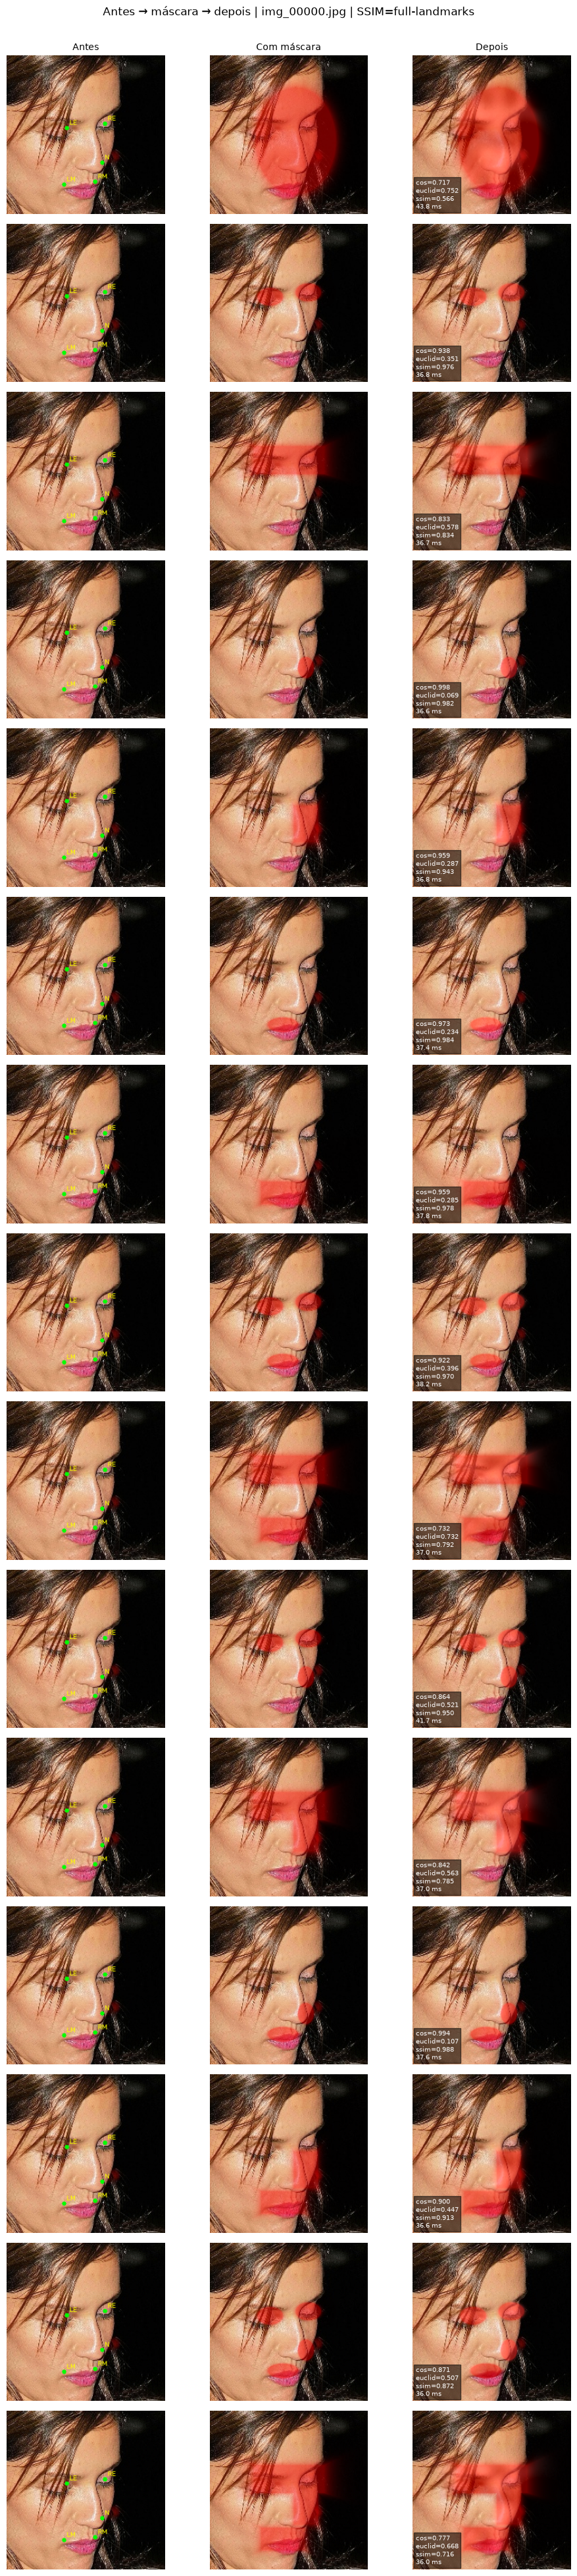

Grid mestre salvo: /mnt/study-data/dcarvalho/tests/final_comparison/master_grid_img_00000.png (15 linhas × 3 colunas)


In [23]:
OVERVIEW_IMAGE_IDX = 0  # índice em sample_paths
COLUMN_LABELS = ("Antes", "Com máscara", "Depois")

overview_paths = sample_paths if "sample_paths" in globals() else list_sample_images(1)
if not overview_paths:
    raise RuntimeError("Nenhuma imagem encontrada em DATA_DIR.")

img_path = overview_paths[min(OVERVIEW_IMAGE_IDX, len(overview_paths) - 1)]
rgb = load_rgb(img_path)
det = detector.detect_best(img_path)
if det is None:
    raise RuntimeError(f"Sem face detectada em {img_path}")

landmarks = det.landmarks.astype(np.float32)
overview_rows: list[dict] = []

for region_label, variants in VISUAL_REGIONS:
    for shape, exp_name, regions_spec in variants:
        if not checkpoint_path(exp_name).exists():
            print(f"Checkpoint ausente (pulando): {exp_name}")
            continue
        mask_np, y_rgb, metrics = run_transform(
            exp_name, rgb, landmarks, shape, regions_spec,
        )
        overview_rows.append({
            "label": f"{region_label} | {shape}",
            "before": draw_landmarks(rgb, landmarks),
            "masked": overlay_mask(rgb, mask_np),
            "after": y_rgb,
            "metrics": metrics,
        })

if not overview_rows:
    raise RuntimeError("Nenhuma linha gerada — verifique checkpoints.")

n_rows = len(overview_rows)
fig, axes = plt.subplots(n_rows, 3, figsize=(10, 2.6 * n_rows))
if n_rows == 1:
    axes = np.expand_dims(axes, 0)

for row, item in enumerate(overview_rows):
    images = (item["before"], item["masked"], item["after"])
    m = item["metrics"]
    for col, (img, lbl) in enumerate(zip(images, COLUMN_LABELS)):
        axes[row, col].imshow(img)
        if row == 0:
            axes[row, col].set_title(lbl, fontsize=10)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(item["label"], fontsize=9, rotation=0, labelpad=72, va="center")
    axes[row, 2].text(
        0.02, 0.02,
        f"cos={m['cos']:.3f}\neuclid={m['euclid']:.3f}\n"
        f"ssim={m['ssim']:.3f}\n{m['time_ms']:.1f} ms",
        transform=axes[row, 2].transAxes,
        fontsize=7,
        color="white",
        bbox=dict(facecolor="black", alpha=0.55, pad=2),
        va="bottom",
    )

fig.suptitle(
    f"Antes → máscara → depois | {img_path.name} | SSIM={SSIM_REGION}",
    fontsize=12,
    y=1.002,
)
fig.tight_layout()
overview_path = OUTPUT_DIR / f"master_grid_{img_path.stem}.png"
fig.savefig(overview_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Grid mestre salvo: {overview_path} ({n_rows} linhas × 3 colunas)")